## 1. Data Loading & Preprocessing Pipeline

At this stage, a "clean" dataset is prepared for time series analysis. The main goal is to ensure the continuity of segments and synchronize real logs with synthetic estimates (Teacher Reconstruction).

### Key pipeline operations:
* **Synchronization:** Loading raw data from `Mood Mart` and converting it to a public format (Data Schema Alignment).
* **Segmentation:** Splitting data into continuous time segments to avoid distortions when calculating autocorrelations (ACF), lags and moving averages.
* **Validation of gaps:** Automatic addition of sub-segments and filtering out too short periods (less than 7 days) that are not representative for dynamics analysis.
* **Slicing:** Dividing data into strategic periods:
* `FULL`: for training the `Teacher` model.
* `MOODS_ONLY`: for final reconstruction and training of the `Student` model.

> **Architectural Note:** Using encapsulated logic in the `segmentation.py` module allows maintaining data integrity between different EDA stages and the final productive simulation.

In [34]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from daily_flow.analytics.datasets.constants import (
    DatasetPeriod,
)
from daily_flow.analytics.datasets.context import (
    get_mood_target_analysis_profiles,
    get_sleep_impact_profiles,
)
from daily_flow.analytics.datasets.correlation import get_clean_cross_corr, get_critical_features
from daily_flow.analytics.datasets.pipeline import prepare_temporal_data, validate_synthetic_logic
from daily_flow.analytics.datasets.schema import (
    FACTORS,
    MOOD_COLUMNS,
)
from daily_flow.analytics.datasets.segmentation import get_clean_segmented_data
from daily_flow.analytics.datasets.time_series import (
    analyze_temporal_memory,
    calculate_feature_lags_matrix,
    get_significant_ccf,
    get_temporal_stats,
)
from daily_flow.analytics.datasets.visualizations import (
    plot_temporal_heatmap,
)

In [35]:
# Run the pipeline:
# df - raw merged dataset for overview
# dfs - dictionary with cleaned and sliced segments (ready for ACF/Cross-Correlation)
df, dfs = get_clean_segmented_data()
# Check the received periods
print(f"Available periods: {list(dfs.keys())}")

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Users\myros\AppData\Local\Programs\Python\Python311\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x00000235135FC080> is already entered
Task was destroyed but it is pending!
task: <Task pending name='Task-208' coro=<_async_in_context.<locals>.run_in_context() done, defined at D:\DS-Projects\daily-flow\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-210' coro=<Kernel.shell_main() running at D:\DS-Projects\daily-flow\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at D:\DS-Projects\daily-flow\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\myros\AppData\Local\Programs\Python\Python311\Lib\selectors.py:327: RuntimeWarning: coroutine 'Kerne

Available periods: [<DatasetPeriod.COMMON_ONLY: 'common_only'>, <DatasetPeriod.MOODS_ONLY: 'moods_only'>, <DatasetPeriod.FULL: 'full'>]


## 2. Target Construction & Factor Isolation

To perform correlation analysis and train the student model, it is necessary to generate a single vector of the target variable (`target_final`). This stage is critical because it allows you to dynamically isolate individual factors to test their influence.

### Main tasks of the stage:
* **Hybrid Target Generation:** Stitching real ratings (`common_mood_log`) with synthetic data obtained from the teacher model.
* **Factor Isolation:** The ability to exclude specific emotions or external factors (e.g. `sleep`) from the calculation of the synthetic to prevent data leakage during relationship analysis.
* **Temporal Consistency:** Ensuring that the synthetic mood is based only on internal emotional markers, leaving external factors for prediction.

> **Methodology:** The `prepare_temporal_data` function allows you to create different dataset configurations for cross-correlation analysis (CCF), which is the foundation for feature selection in Stage 3.

In [36]:
df_temp = prepare_temporal_data(
    dfs, [DatasetPeriod.FULL, DatasetPeriod.MOODS_ONLY], factors_to_exclude=FACTORS
)

## 3. Temporal Dynamics — ACF and PACF Analysis
This analysis stage selects the “memory” of the system and establishes which time lags will form the basis for the predictive model in stage 3.

164


AnalysisProfiles.HISTORICAL | Threshold: 0.179


,lag,acf,pacf,is_significant
13,13,0.194175,0.244763,True
1,1,0.225844,0.242228,True
16,16,-0.147104,-0.188491,True
21,21,0.154138,0.181623,True
6,6,0.138577,0.168330,False


ADF Statistic for AnalysisProfiles.HISTORICAL: -8.152, p-value: 0.000

AnalysisProfiles.SYNTHETIC_BRIDGE | Threshold: 0.153


,lag,acf,pacf,is_significant
1,1,0.380682,0.384759,True
10,10,-0.115719,-0.217269,True
15,15,-0.195287,-0.194466,True
4,4,0.151005,0.178605,True
22,22,0.039555,0.153676,True


ADF Statistic for AnalysisProfiles.SYNTHETIC_BRIDGE: -8.405, p-value: 0.000

AnalysisProfiles.MODERN_FULL | Threshold: 0.223


,lag,acf,pacf,is_significant
10,10,-0.230196,-0.327465,True
15,15,-0.186176,-0.287094,True
18,18,-0.138638,-0.276786,True
29,29,0.205693,0.273669,True
25,25,0.122599,0.258013,True


ADF Statistic for AnalysisProfiles.MODERN_FULL: -6.814, p-value: 0.000


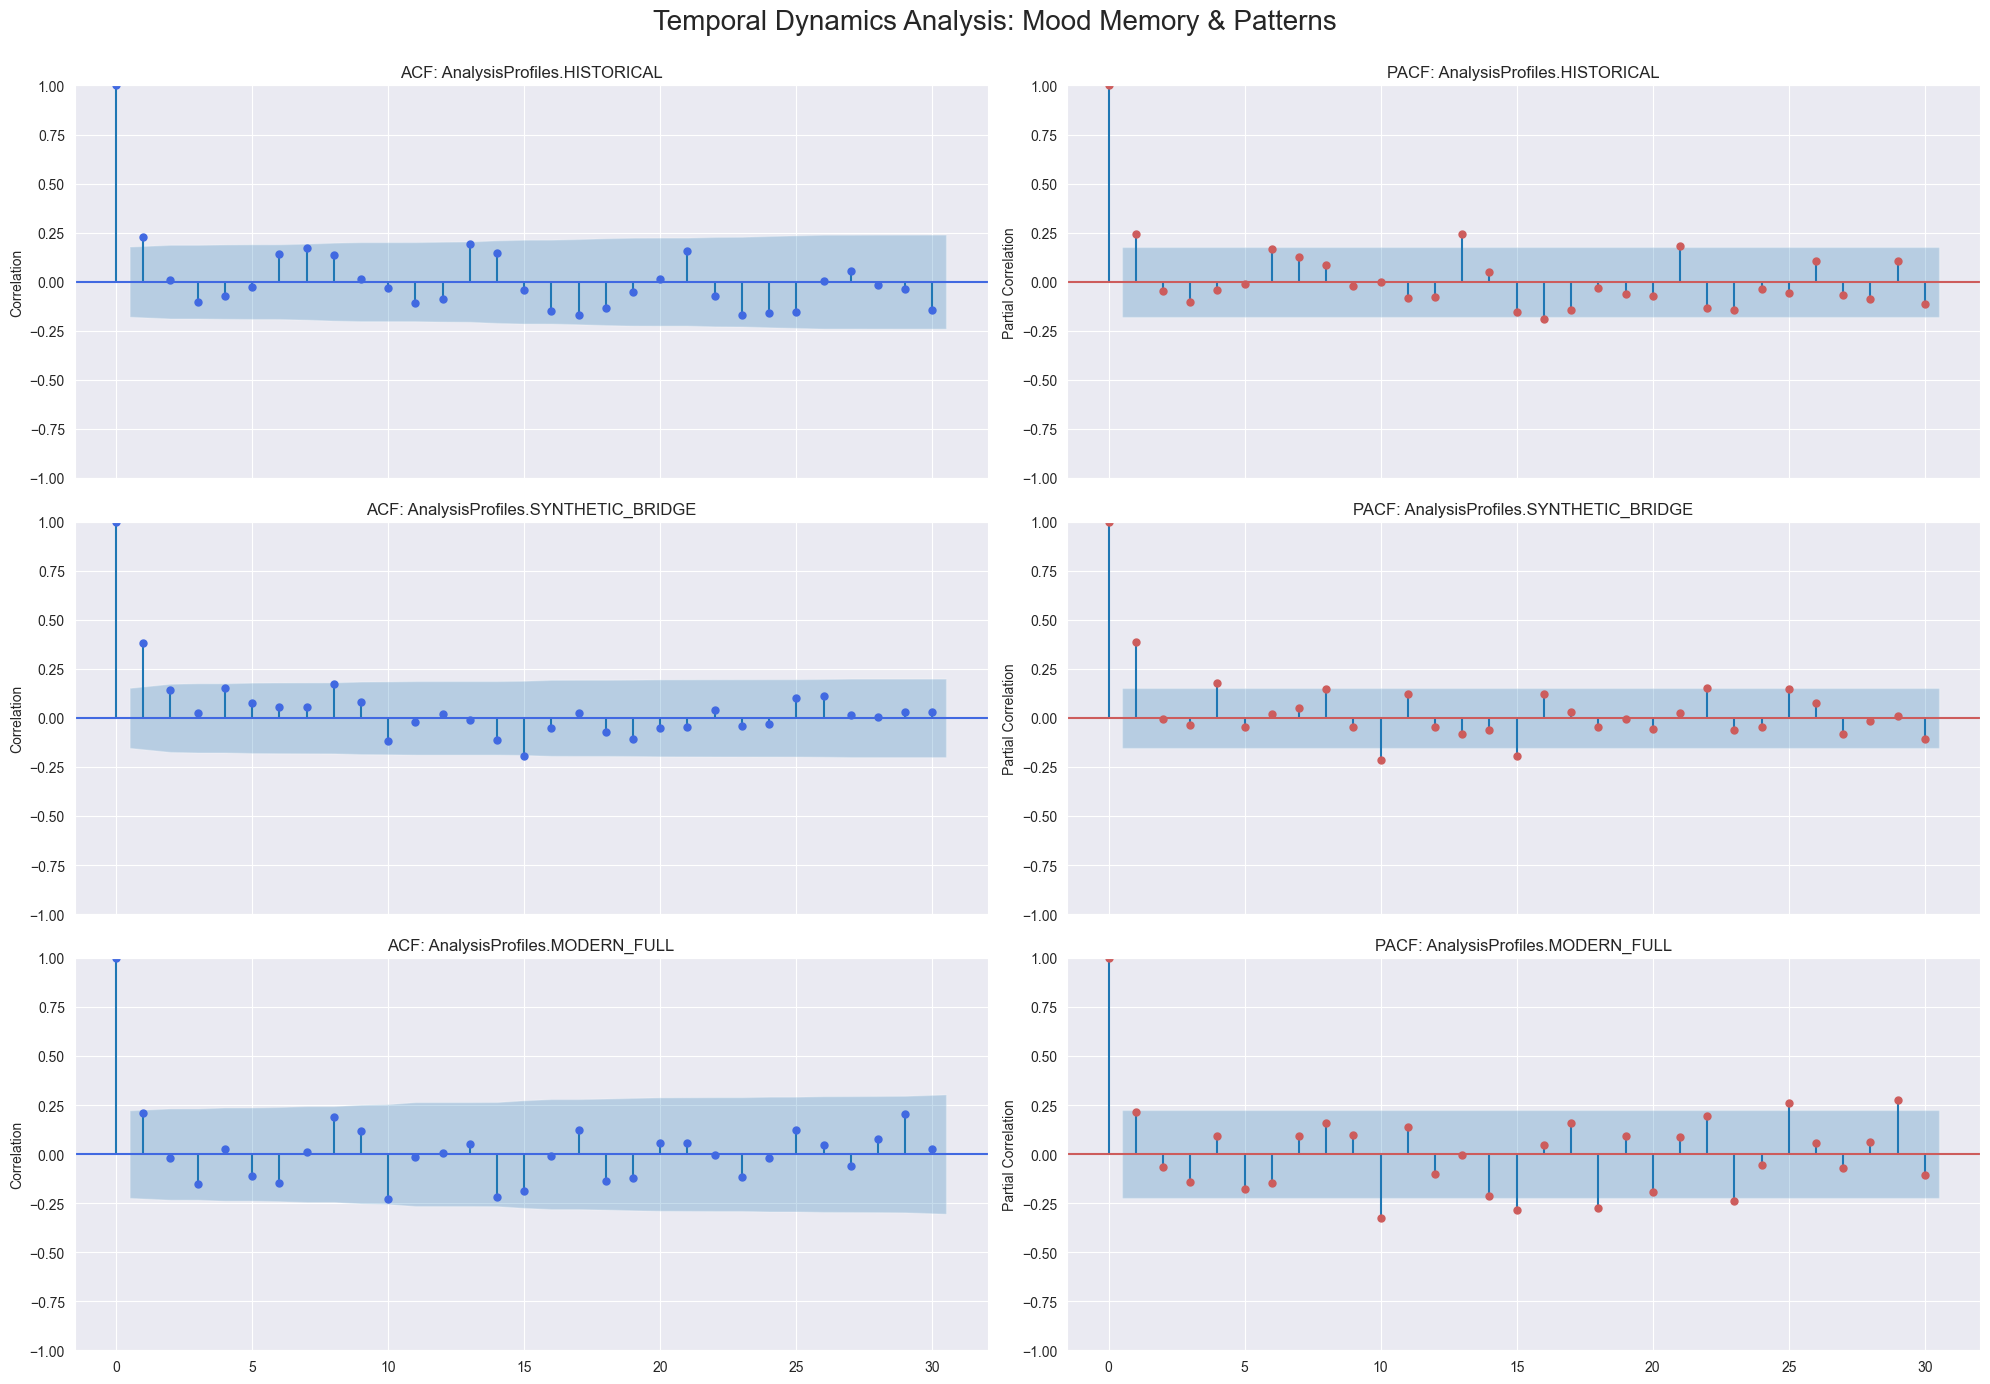

In [38]:
display(len(df_temp))
mood_target_analysis_profiles = get_mood_target_analysis_profiles(dfs, df_temp)

for name, series in mood_target_analysis_profiles.items():
    lags_df, conf_level = get_temporal_stats(series)

    lags = lags_df[lags_df["lag"] > 0].copy()
    lags["pacf_abs"] = lags["pacf"].abs()
    top_lags = lags.sort_values(by=["is_significant", "pacf_abs"], ascending=False).head(5)

    print(f"\n{name} | Threshold: {conf_level:.3f}")
    display(top_lags[["lag", "acf", "pacf", "is_significant"]])

    result = adfuller(series.dropna())
    print(f"ADF Statistic for {name}: {result[0]:.3f}, p-value: {result[1]:.3f}")

fig, axes = plt.subplots(len(mood_target_analysis_profiles), 2, figsize=(20, 15), sharex=True)

for i, (name, series) in enumerate(mood_target_analysis_profiles.items()):
    plot_acf(series, lags=30, ax=axes[i, 0], title=f"ACF: {name}", color="royalblue")

    plot_pacf(
        series, lags=30, ax=axes[i, 1], method="ols", title=f"PACF: {name}", color="indianred"
    )

    axes[i, 0].set_ylabel("Correlation")
    axes[i, 1].set_ylabel("Partial Correlation")

plt.suptitle("Temporal Dynamics Analysis: Mood Memory & Patterns", fontsize=20, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Key findings
#### 1. General characteristics of time series
* **Stationarity:** A rapid decay of ACF is observed on all data segments (Historical, Modern, Synthetic). The series are **stationary**, which allows building a model without additional differentiation.
* **Smoothing Effect:** Using a synthetic target (`total_mood`) on a continuous series increased the autocorrelation of Lag 1 to **~0.38**. This confirms that emotional decomposition preserves state inertia better than rough subjective ratings 1-5.

#### 2. Analysis of significant lags (Feature Selection)
Based on the comparison of ACF and PACF, we selected "pure" predictors, filtering out noise and indirect correlations.

| Lag (Days) | Signal (PACF) | Interpretation and role in the model |
| :--- | :--- | :--- |
| **Lag 1** | **Strong** | **Yesterday.** Main predictor. Correlation ~0.35 is ideal: sufficient for training, but does not overtrain the model. |
| **Lag 2** | **Vanishing** | **The day before yesterday.** The signal disappears on the PACF. This means that Lag 1 already contains all the necessary information about the previous day. Can be ignored as a separate feature. |
| **Lag 4** | **Moderate** | **Micro-cycle.** Expressed on modern data. Probably related to the work week rhythm or the accumulation of fatigue. |
| **Lag 10** | **Moderate** | **Stable rhythm.** Significant spike on the PACF. May be an echo of biorhythms or the cyclical nature of work sprints. |
| **Lag 15** | **Borderline** | **Two-week cycle.** Appears on synthetics and modern data. Worth testing as an additional feature. |
| **Lag 8, 13** | **Weak/Noise** | Were significant on ACF, but disappeared on PACF. This is just an "echo" of shorter lags (e.g. 4+4). |

#### 3. Comparing periods (Nature Shift)
* **Historical Logs (Common Only):** Demonstrate sinusoidal decay (**Sinusoidal Decay**) on ACF — characteristic "waves". On PACF, these waves break after Lag 1. This proves that the old data had high subjective cyclicality, which was just an "echo" of yesterday.
* **Modern & Synthetic Data:** More stable and closer to the mean (mean reversion). The appearance of clear peaks at 4 and 10 lags (even without "waves") indicates that the new data collection system (Full) better captures real biorhythms.

#### 4. Final Strategy for Stage 3 (Feature Engineering)
Based on the analysis, we can consider the following features for the model:

1. **Direct AR Features:** `mood_lag_1`, `mood_lag_4`, `mood_lag_10`. (Lag 15 is optional).

2. **Weighting Strategy:** Give higher weight to data from `Modern Logs`, since their temporal structure (PACF) is more relevant to the current life rhythm.
3. **Data Integrity:** We confirmed the structure of the logs using synthetics, but for training the model (to avoid Data Leakage) we will use only "clean" logs.
4. **Synthetic Bridge (Full + Moods) usage:** The plan to use this data for training, after Stage1 and Stage2 is still relevant.

**Verdict:** The series are stationary, direct predictors are determined. You can proceed to the analysis of external factors (Cross-Correlation).

## 4. Cross-Correlation Analysis (Sleep vs Mood)
At this stage, we investigate the external influence of sleep quality on emotional state. CCF analysis allows us to determine not only the strength of the connection, but also the time lag with which physical recovery is transformed into psychological resource.

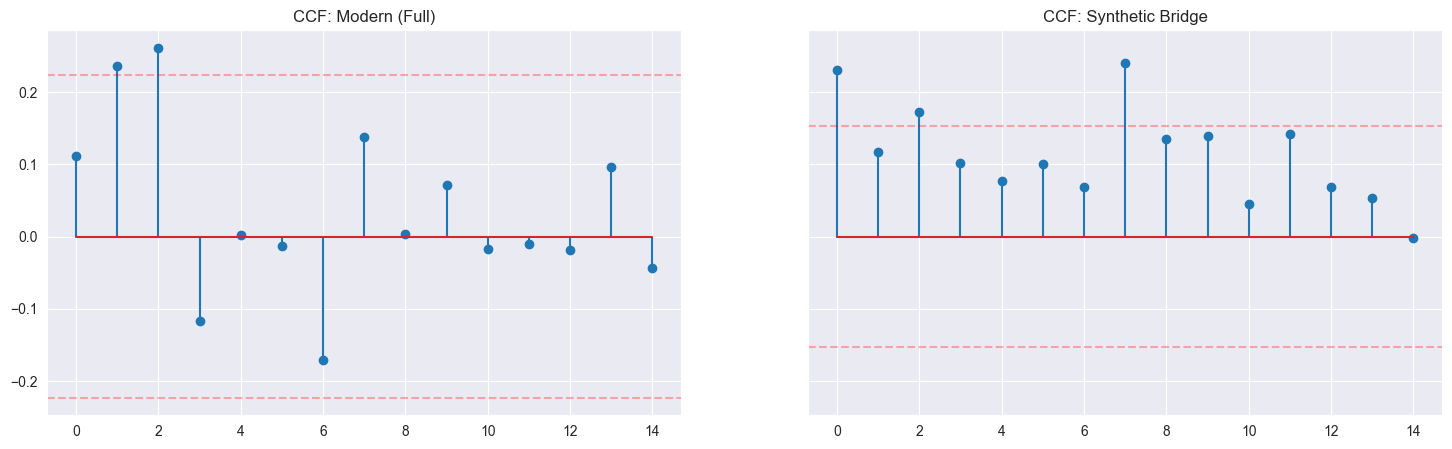

,Lag,Correlation,Significant,threshold,Source
1,2,0.262,True,0.223,Modern (Full)
0,1,0.237,True,0.223,Modern (Full)
2,7,0.241,True,0.153,Synthetic Bridge
0,0,0.231,True,0.153,Synthetic Bridge
1,2,0.173,True,0.153,Synthetic Bridge


In [40]:
nlags = 15
sleep_impact_profiles = get_sleep_impact_profiles(dfs, df_temp)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
summary_list = []

for i, (profile_type, (mood_series, sleep_series)) in enumerate(sleep_impact_profiles.items()):
    name = profile_type.value

    corr_values, sig_lags_df, conf_level = get_significant_ccf(
        mood_series, sleep_series, nlags=nlags
    )
    if not sig_lags_df.empty:
        sig_lags_df["Source"] = name
        summary_list.append(sig_lags_df)

    axes[i].stem(range(nlags), corr_values)
    axes[i].axhline(y=conf_level, color="r", linestyle="--", alpha=0.3)
    axes[i].axhline(y=-conf_level, color="r", linestyle="--", alpha=0.3)
    axes[i].set_title(f"CCF: {name}")

plt.show()

if summary_list:
    full_results = pd.concat(summary_list)
    full_results["abs_corr"] = full_results["Correlation"].abs()
    display(
        full_results.sort_values(by=["Source", "abs_corr"], ascending=[True, False]).drop(
            columns=["abs_corr"]
        )
    )

### Key Findings

#### 1. Physical Inertia and "Delayed Recovery"
* **Lag 2 (Primary Signal):** The strongest correlation peak (**0.262**) is observed on the second day after sleep. This indicates the effect of accumulated recovery: today's sleep quality is maximally reflected on mood not tomorrow, but the day after tomorrow.
* **Lag 1 (Next-day impact):** The direct impact of the next day is also significant (**0.237**), which confirms the stability of the physiological signal in `Modern Logs`.

#### 2. Synthetic Bridge Resonance
* **Lag 0 (Direct impact):** In the mixed data, a significant correlation appears on the day of sleep (**0.231**). This indicates that the emotional decomposition in the new data collection system responds more quickly to sleep deficit or surplus.
* **Lag 7 (Weekly resonance):** A weekly cyclicity is detected (**0.241**). The quality of sleep on a specific day of the week (e.g., weekend) correlates with the emotional background of the same day the following week, which emphasizes the impact of a stable routine.

#### 3. Profile Comparison (Data Integrity)
* **Consistency:** The signal at **Lag 2** is preserved in both profiles (0.262 in Modern vs 0.173 in Synthetic). Although it is somewhat weaker in synthetic, the preservation of the vector and significance confirms the relevance of `Synthetic Bridge` for training the model.

### Feature Engineering Strategy (Stage 3)

Based on CCF analysis, the following predictors were selected for the feature catalog:

| Feature | Lag | Priority | Interpretation |
| :--- | :--- | :--- | :--- |
| **sleep_lag_2** | 2 days | **High (7)** | **Delayed Recovery.** Key marker of physiological inertia. |
| **sleep_lag_0** | 0 days | **High (6)** | **Direct Impact.** Instant system response to sleep quality. |
| **sleep_lag_7** | 7 days | **Med (5)** | **Weekly Rhythm.** Resonance of weekly schedule and routine. |
| **sleep_lag_1** | 1 day | **Low (3)** | **Next-day Echo.** Additional signal to refine the forecast. |

**Verdict:** Cross-correlation analysis confirmed the presence of a robust relationship between sleep and mood. The identified lags (0, 2, 7) have a clear biological interpretation and will be used as exogenous variables in the final Stage 3 model.

## 5. Correlation analysis of emotional markers (Lag Analysis)
At this stage, we investigate how individual emotions correlate with the overall mood indicator (`target_final`) at different time lags. This will allow us to identify which emotions have an immediate effect and which have a delayed (cumulative) effect.

### Factor isolation methodology (Anti-Leakage)
To obtain objective results, we use dynamic target formation:
* **Avoidance of self-correlation:** When analyzing a specific emotion (for example, *Joy*), we use the `prepare_temporal_data` function to exclude it from the synthetic mood calculation algorithm.
* **Objectivity:** This ensures that the high correlation coefficient in the CCF is the result of a real connection of states in time, and not a consequence of the emotion being part of the mathematical formula of the target.

### 5.1. Stability Validation (Leave-One-Out)
Before bulk calculation of CCF, we perform a stress test on the interval `DatasetPeriod.FULL`:
1. We exclude each emotion in turn from the calculation of the general background.
2. We calculate the Pearson correlation between the "incomplete" synthetic indicator and the real log (`common_mood_log`).
3. **Goal:** To make sure that the general mood indicator is a stable metric that does not collapse in the absence of one of the components.

> **Result:** This approach allows us to fairly estimate the lags of all emotions in point 5, avoiding the "trivial" correlations (0.9+) that arise when comparing the part with the whole.

In [42]:
validation_report = validate_synthetic_logic(dfs, DatasetPeriod.FULL)

print("Stability Report: Synthetic Mood vs Real Logs")
display(validation_report)

Stability Report: Synthetic Mood vs Real Logs


,Excluded_Emotion,Correlation_r,P_value,Status
6,irritation,0.786,0.0,✅ Stable
2,calm,0.778,0.0,✅ Stable
4,anxiety,0.778,0.0,✅ Stable
8,fear,0.775,0.0,✅ Stable
5,sadness,0.768,0.0,✅ Stable
9,confidence,0.763,0.0,✅ Stable
7,fatigue,0.745,0.0,✅ Stable
3,energy,0.739,0.0,✅ Stable
1,interest,0.735,0.0,✅ Stable
0,joy,0.714,0.0,✅ Stable


### Validation of the stability of the target variable (Stability Report)

Before conducting the mass calculation of cross-correlations (CCF) in point 5, we conducted a stress test of the metric using the **Leave-One-Out** methodology. The results confirm the high reliability of the formed target:

* **High consistency:** Removing any emotion from the calculation does not collapse the correlation with the real log (`common_mood_log`). The coefficients remain within **0.71 – 0.79**, which indicates balanced weights.
* **Absence of a dominant factor:** No emotion (even the strongest ones, such as *irritation* or *calm*) is a critical point of failure. This means that the synthetic mood is a **complex indicator**, and not just a duplicate of one of the markers.
* **Status "Stable":** All tests passed the significance threshold ($p < 0.05$). This gives the "green light" to use this target in time lag analysis.

**Conclusion:** The metric is mathematically stable. We can proceed to calculate the CCF for each emotion separately, excluding it from the target to avoid autocorrelation.

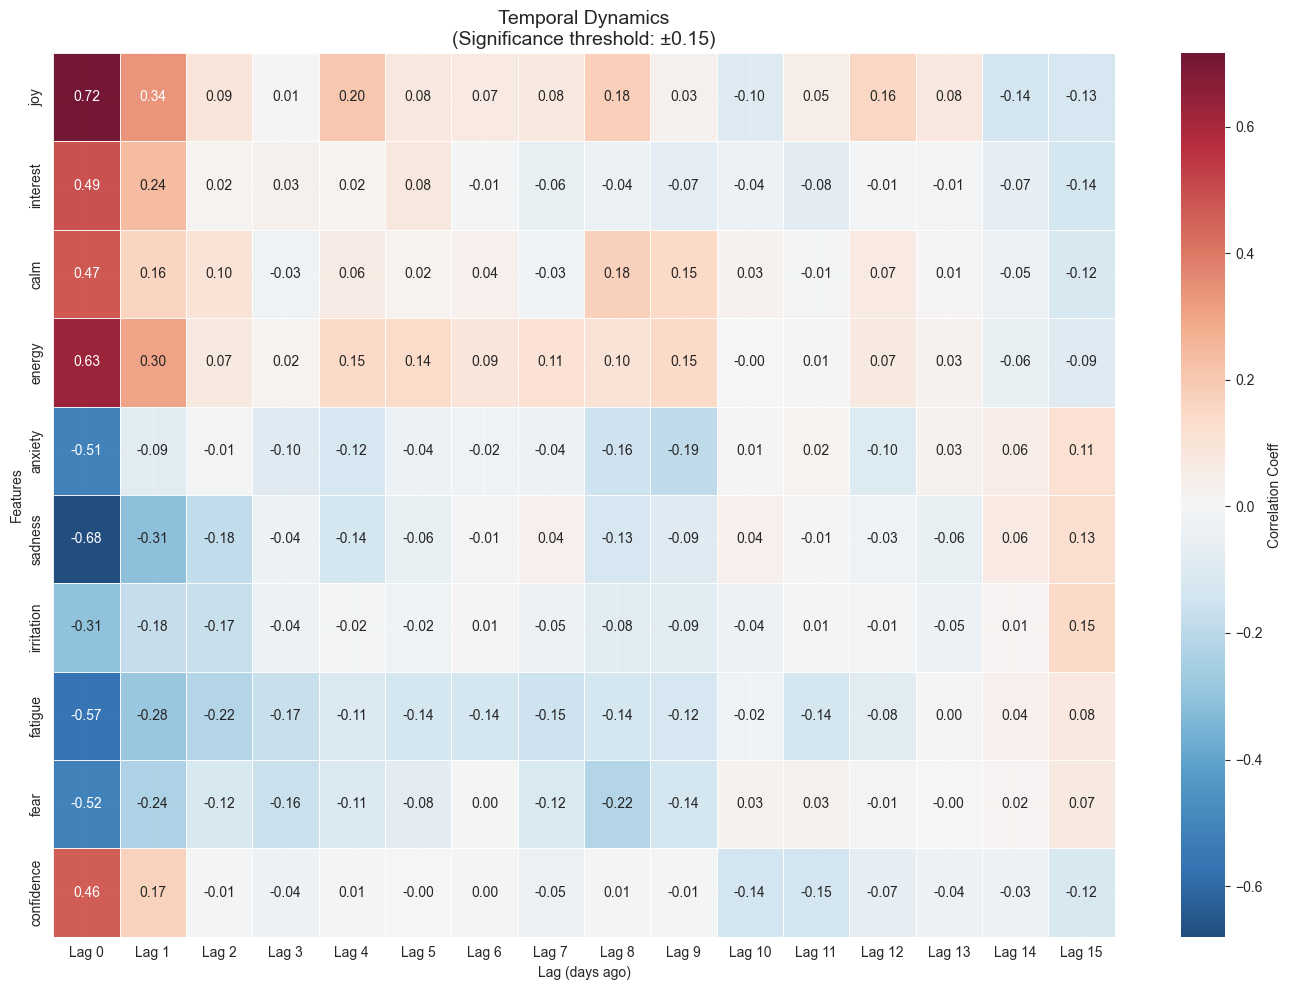

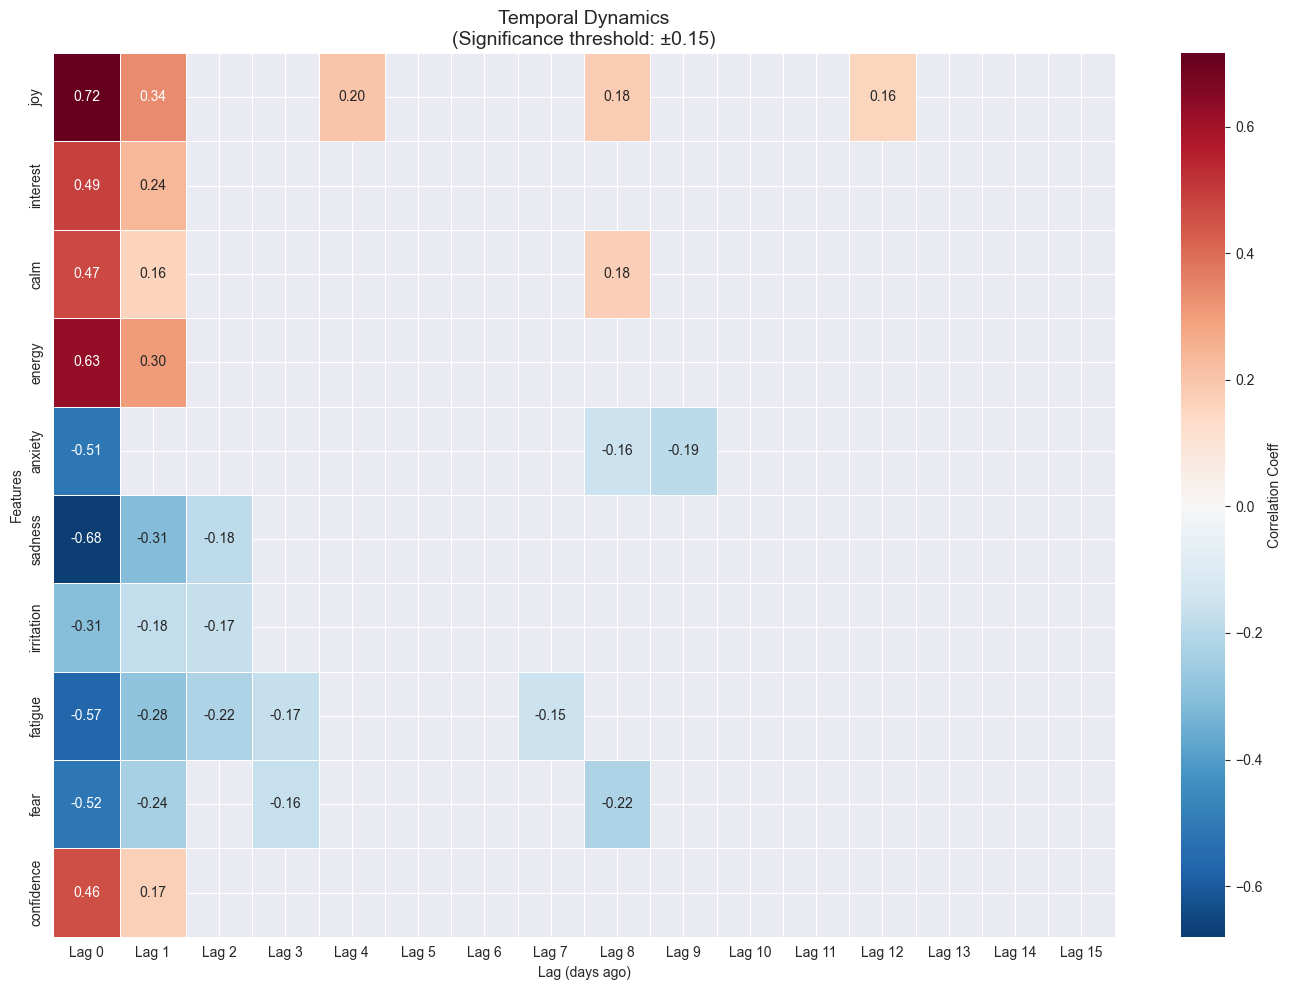

In [43]:
moods_features = [c for c in MOOD_COLUMNS if c not in FACTORS]
ccf_synthetic_bridge_matrix, synthetic_bridge_threshold = calculate_feature_lags_matrix(
    dfs, moods_features, [DatasetPeriod.FULL, DatasetPeriod.MOODS_ONLY]
)
plot_temporal_heatmap(ccf_synthetic_bridge_matrix, synthetic_bridge_threshold, with_noise=True)
plot_temporal_heatmap(ccf_synthetic_bridge_matrix, synthetic_bridge_threshold, with_noise=False)

#### Let's now do the same for the period `FULL`

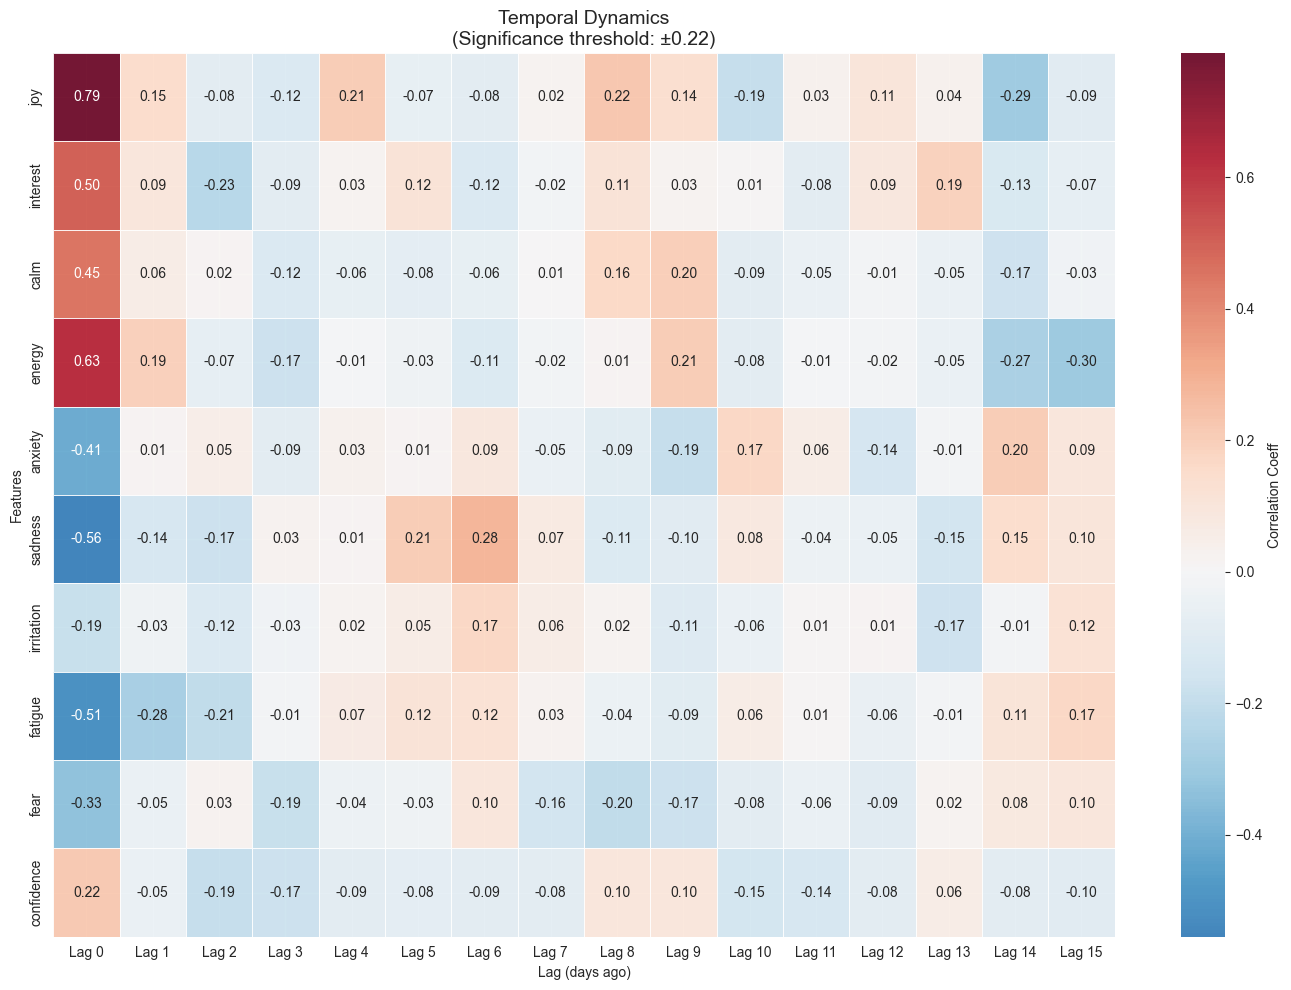

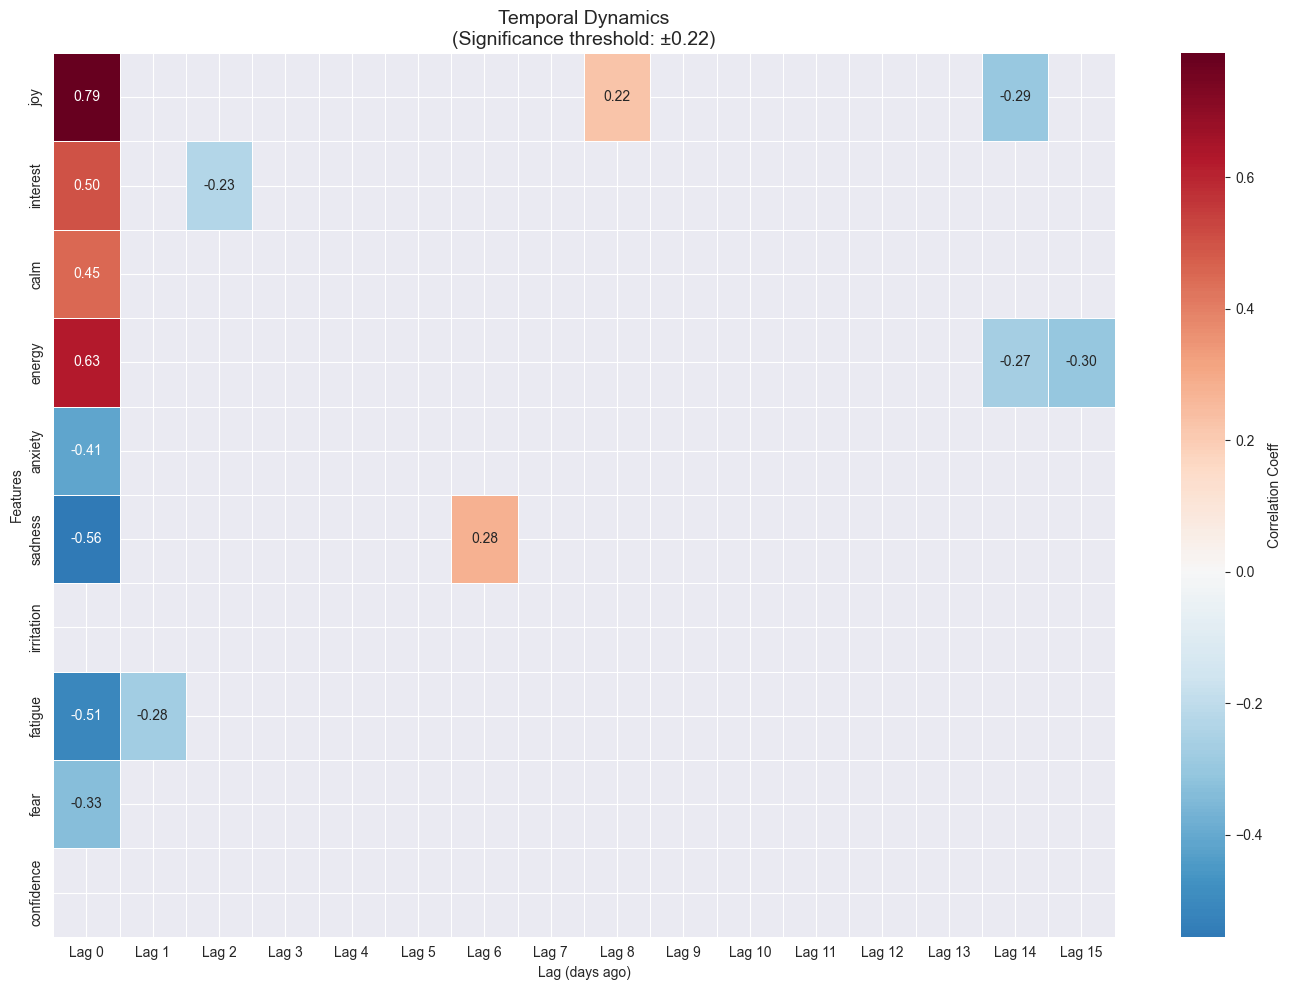

In [45]:
moods_features = [c for c in MOOD_COLUMNS if c not in FACTORS]
ccf_modern_full_matrix, modern_full_threshold = calculate_feature_lags_matrix(
    dfs, moods_features, [DatasetPeriod.FULL]
)

plot_temporal_heatmap(ccf_modern_full_matrix, modern_full_threshold, with_noise=True)
plot_temporal_heatmap(ccf_modern_full_matrix, modern_full_threshold, with_noise=False)

### Key Findings, CCF Analysis (Technical Summary)

This section analyzes cross-correlation functions (CCFs) to identify the time lags that have the highest statistical significance for predicting the target variable (`common_mood_log`). The analysis is conducted on both historical data and combined sets with the use of synthetic proxy data to detect hidden cycles.

Synthetic data is used exclusively for stress testing the detected cycles on a longer time horizon, while the base lags are selected according to the FULL log

#### 1. Short-term inertia (Lag 1-3)
* **Autoregressive effect:** The respondent's mood shows a stable correlation with the previous day's indicators ($Lag 1$). The coefficients for **Joy (0.34), **Energy (0.30), and **Fatigue (-0.28)** confirm that the state "yesterday" is a significant predictor of "today", although this relationship is not deterministic. The strongest and most stable signal on the synthetic data shows **Fatigue**.
* **State stability:** **Fatigue** and **Sadness** retain their influence up to 3 days ($Lag 3$). This indicates the inertia of negative states - they need more time to "fade out" compared to reactive emotions.
* **Lag 2:** Statistically significant for modeling protracted states.
* **Lag 3:** Acts as a boundary marker of significant inertia; everything else is cyclical, not inertia - if we are talking about `FULL` data.

#### 2. Weekly resonance and social cycles (Lag 7-9)
* **Stress synchronization:** A clear cluster of significance was found for **Calm** and **Anxiety** on days 8-9. This confirms the hypothesis about a weekly work cycle (the influence of last Monday on the current Tuesday).
* **(Lag 6-7):** An anomalous positive correlation of the sum of 6-day history with the current mood was found. This is probably the effect of relief after the end of a difficult weekly cycle. It is worth noting that this is observed only on full data - so this is more of an observation than a one hundred percent feature.

#### 3. The phenomenon of negative autocorrelation on a 14-day cycle
* **Inversion of positive emotions:** A strong insight was revealed - positive states (**Joy, Energy, Interest**) 14-15 days ago have a negative correlation with current mood (for example, **Joy Lag 14: -0.29**, **Energy Lag 15: -0.30**). This is mathematical confirmation of the burnout cycle: a period of high emotional uplift is followed by a phase of "energy accounting" after two weeks.
* **Recovery Signal:** On the contrary, high **Fatigue** with a lag of 15 days correlates with the current mood uplift. This indicates that the points of deep rest lay the foundation for a positive trend after two weeks, but it is worth noting that these values do not break the threshold of significance. You can also see that on synthetic data, which have a longer observation period, this is less pronounced, unlike the `FULL` period.

#### 4. Synchronization of noisy features
* **"Confidence" and "Irritation" are noisy:** There is noise throughout the interval, so it is not advisable to use them as an inference in modeling.
* **About "Confidence" and "Irritation" on the 15th day:** The fact that even these "noisy" features start to show movement on the 15th day is a very strong marker. This means that the 14-day cycle is so powerful that it synchronizes even those emotions that are usually chaotic. For the model, this can be a "super-feature" for long-term forecasting.

#### 5. Complex oscillation of "Joy"
The **Joy** indicator has its own harmonic structure, which the model should take into account as a wave process:
* **Peaks:** 4, 8, 12 days (resource recovery cycles).
* **Slumps:** 6, 10 and especially 14 days (planned emotional correction points).

---

### Final lag selection table for the M2 model

To prevent overfitting and optimize the feature space, it is recommended to include the following lags in the **M2** model:

| Feature (Emotion) | Recommended lags ($T-k$) | Rating | Justification |
| :--- | :--- | :--- | :--- |
| **Joy, Energy** | **14, 15** | **5/5** | **Unique Insight.** Predictors of the burnout phase and “energy debt”. |
| **Fatigue** | **1** | **5/5** | **Core Feature.** The most stable feature with the lowest noise level. |
| **Joy** | **1, 4, 8** | **5/5** | Basic emotional background and internal 4-day cyclicality. |
| **Interest, Sadness, Energy, Calm** | **1** | **5/5** | Necessary for modeling the inertia of “yesterday”. |
| **Calm, Anxiety** | **8, 9** | **4/5** | Markers of weekly seasonality (social cycle). |
| **Fatigue, Sadness** | **2, 3** | **4/5** | Important for fixing prolonged states of fatigue or depression. |
| **Fear, Interest** | **1, 2** | **4/5** | Predictors of short-term anxiety and engagement. |
| **Joy** | **12** | **3/5** | Long-term seasonality (4-day cycle harmonics). |
| **Irritation** | **1** | **3/5** | Optional: signal of current emotional reactivity. |
| **Fatigue, Fear, Sadness** | **6, 7, 8** | **2/5** | Experimental signals of “weekly bounce”. |
| **Confidence, Irritation** | **> 1** | **1/5** | High noise; virtually no predictive power. |

---

### Conclusions for the modeling stage (Stage 3: Forecasting)

1. **Data Leakage Protection:** All emotion features in the **M2** model must have a shift of at least one step ($T-1$). Using $Lag 0$ is permissible only for independent external factors that are known at the time of the forecast.
2. **Feature Engineering (Smoothing):** For inert features (**Fatigue, Sadness**), it is advisable to create `rolling_mean(3d)` to clean the signal from daily noise and focus on the trend.
3. **Seasonal accounting:** The presence of clear lags of 7 and 14 days indicates the need to use models that can take seasonality into account (for example, SARIMA or LSTM with an appropriate attention window). Given the detected 14-day seasonality, the use of SARIMA (with parameter S=14) or LSTM with a lookback window of at least 15-21 days seems most relevant.

## 6. Temporal Memory Analysis
Goal: To determine how long mood "remembers" its previous state and select optimal time windows for the M2 model.

In [47]:
df_real = prepare_temporal_data(dfs, [DatasetPeriod.FULL])
print(f"{len(df_real)=}")

# 1. Raw Log Analysis (Real Logs)
# Checking if mood has "self-correlation" without processing
mood_memory_real = analyze_temporal_memory(df_real, "common_mood_log", "common_mood_log")
print(
    f"Count of significant raws "
    f"for mood_memory_real: {len(mood_memory_real[mood_memory_real['is_significant']])}"
)

# 2. Hybrid Analysis (Synthetic -> Real)
# Checking how the synthetic index predicts real sentiment
mood_memory_hybrid_cross = analyze_temporal_memory(
    df_real, "total_mood_synthetic", "common_mood_log"
)
print(
    f"Count of significant raws for mood_memory_hybrid_cross:"
    f"{len(mood_memory_real[mood_memory_real['is_significant']])}"
)


print(f"{len(df_temp)=}")
# 3. Final Target
# Autocorrelation analysis of our main target variable for M2
target_memory_results = analyze_temporal_memory(df_temp, "target_final", "target_final")

# Display only statistically significant results (p-value < 0.05)
print("--- Significant Target Memory Features ---")
display(target_memory_results[target_memory_results["is_significant"]].head(10))

len(df_real)=77
Count of significant raws for mood_memory_real: 0
Count of significant raws for mood_memory_hybrid_cross: 0
len(df_temp)=164
--- Significant Target Memory Features ---


,correlation,p_value,is_significant
feature,,,
target_final_sma_1d,0.382715,4.610110e-07,True
target_final_ewm_1,0.382715,4.610110e-07,True
target_final_ewm_2,0.364348,1.741952e-06,True
target_final_ewm_3,0.345423,6.304152e-06,True
target_final_ewm_4,0.330788,1.612272e-05,True
target_final_ewm_5,0.318501,3.420816e-05,True
target_final_sma_2d,0.315725,4.265941e-05,True
target_final_ewm_6,0.307360,6.580666e-05,True
target_final_ewm_7,0.296867,1.190444e-04,True


#### 1. The "short window" problem (Real Logs & Synthetic)
The first two analysis scenarios are based on a sample of **2–3 months**. This volume turned out to be insufficient to overcome statistical noise:
* **Lack of observations ($n$):** Even if internal sentiment inertia exists, the small number of points does not allow the $p$-value to fall below the significance threshold ($0.05$).
* **Mathematical aspect:** On short time scales, random fluctuations (noise) dominate the weak autocorrelation signal, blurring the pattern.

#### 2. The advantage of the "long tail" (Target Final)
The hybrid dataset covers almost **6 months** of logs. The doubling of the sample size was crucial for the result:
* **Statistical power:** Doubling the number of observations critically increased the ability of the tests to detect real relationships.
* **Pattern Detection:** This allowed the model to "see" the persistent memory of emotional state that was mathematically hidden in smaller amounts of data.

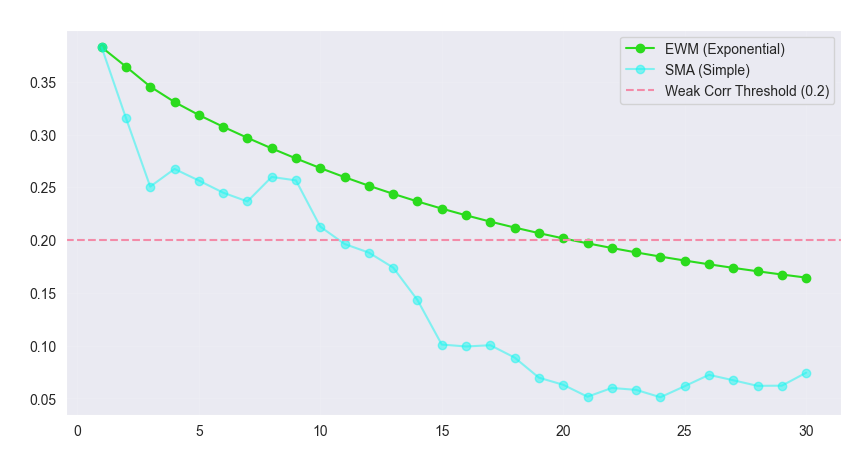

In [48]:
def plot_memory_decay(results_df, feature_prefix):
    def get_data(suffix):
        data = results_df[results_df.index.str.contains(f"_{suffix}_")].copy()
        data["window"] = data.index.str.extract(r"(\d+)").astype(int).values
        return data.sort_values("window")

    ewm, sma = get_data("ewm"), get_data("sma")

    plt.figure(figsize=(10, 5))
    plt.plot(ewm["window"], ewm["correlation"], "o-", color="#2bdb1d", label="EWM (Exponential)")
    plt.plot(
        sma["window"], sma["correlation"], "o-", color="#16f7f0", alpha=0.5, label="SMA (Simple)"
    )
    plt.axhline(0.2, color="#f38ba8", linestyle="--", label="Weak Corr Threshold (0.2)")

    plt.title(f"Memory Decay: {feature_prefix}", color="white")
    plt.xlabel("Days", color="white")
    plt.ylabel("Correlation", color="white")
    plt.legend()
    plt.grid(True, alpha=0.1)
    plt.show()


plot_memory_decay(target_memory_results, "target_final")

### Key Findings, Temporal Feature Selection Strategy

Based on the analysis of **Memory Decay Curve** , we determined the optimal memory depth for the $M2$ model.

* **Lag 1 (Base):** Already added to the catalog earlier as a critical indicator of emotional inertia ($r=0.38$).
* **EWM 5 (Week Context):** Selected as the "break" point of the curve. Reflects the cumulative mood of the work week.
* **EWM 12 (Baseline):** The marginal window of significance. Determines the stable background mood of the last 2 weeks.
* **Experimental options:** We add two additional windows to test the hypotheses of ultra-long memory (21 days) and ultra-short "bounce" (3 days).

**EWM Rationale:** We use exponential smoothing because it has a higher correlation with the target and better models natural memory decay compared to SMA.

### 7. Emotion Time Windows and "Clean" Target

The goal of this stage is to find the strongest temporal features (Memory Features) while avoiding mathematical self-deception. For each emotion, we recalculate the target variable, **excluding** the current emotion from its composition, to see the real predictive impact, not the technical correlation.

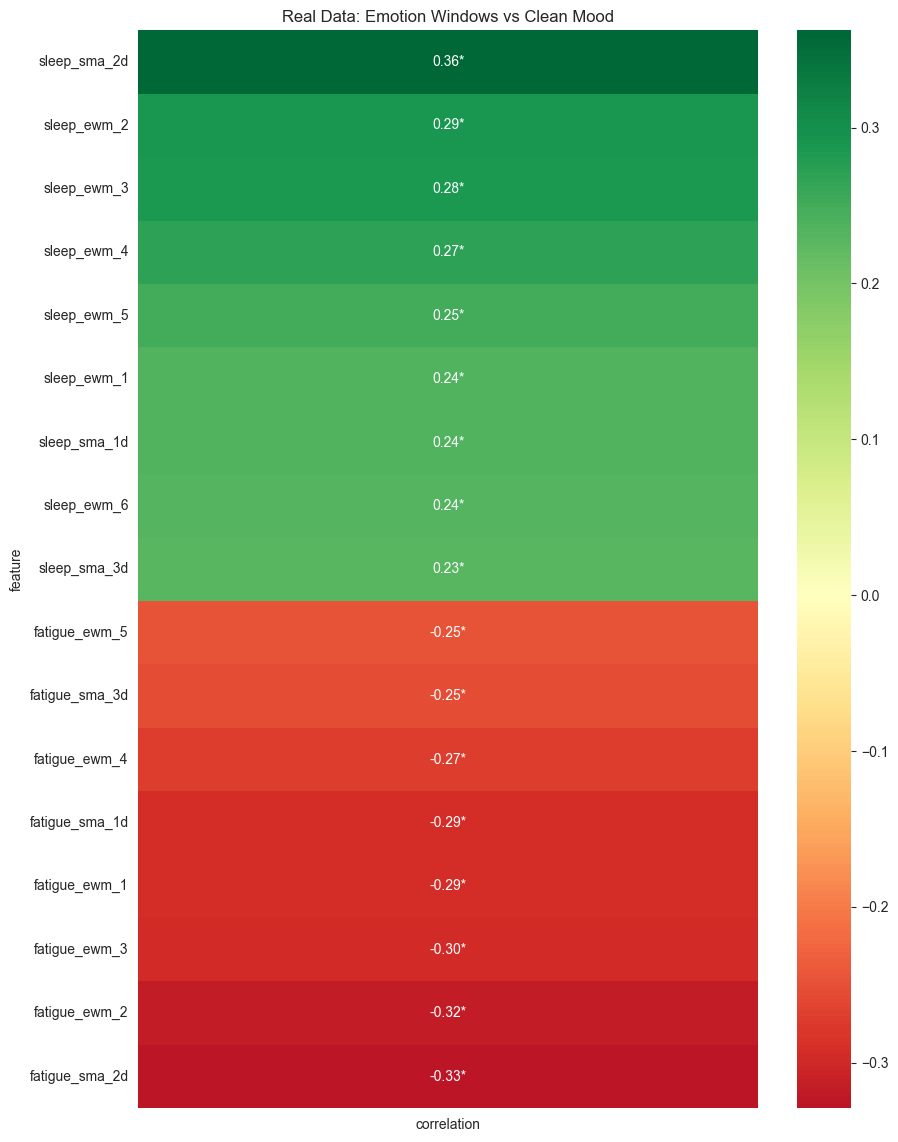

In [50]:
def plot_stat_heatmap(df, title):
    plt.figure(figsize=(10, 14), facecolor="white")

    annotations = df.apply(
        lambda x: f"{x['correlation']:.2f}{'*' if x['is_significant'] else ''}", axis=1
    ).values
    annotations = annotations.reshape(-1, 1)

    sns.heatmap(df[["correlation"]], annot=annotations, fmt="", cmap="RdYlGn", center=0)
    plt.title(title)
    plt.show()


# Experiment A: Real data only
stats_real = get_clean_cross_corr(dfs, target_type="real")
real_sig = stats_real[stats_real["is_significant"]].sort_values("correlation", ascending=False)
plot_stat_heatmap(real_sig, "Real Data: Emotion Windows vs Clean Mood")

# Experiment B: Mix (Synthetic + Real)
stats_mixed = get_clean_cross_corr(dfs, target_type="mixed")
mixed_sig = stats_mixed[stats_mixed["is_significant"]].sort_values("correlation", ascending=False)

#### Analysis of the first two experiments
* **Real Data (Figure 1):** Analysis on pure logs showed the dominance of physical factors. `sleep` has a stable positive effect, and `fatigue` has the strongest negative association -0.33.
* **Mixed Data (Figure 2):** Adding the synthetic bridge expanded the feature space. Here we see a long "tail" of significant correlations for joy, energy, and sadness, confirming the presence of emotional inertia.

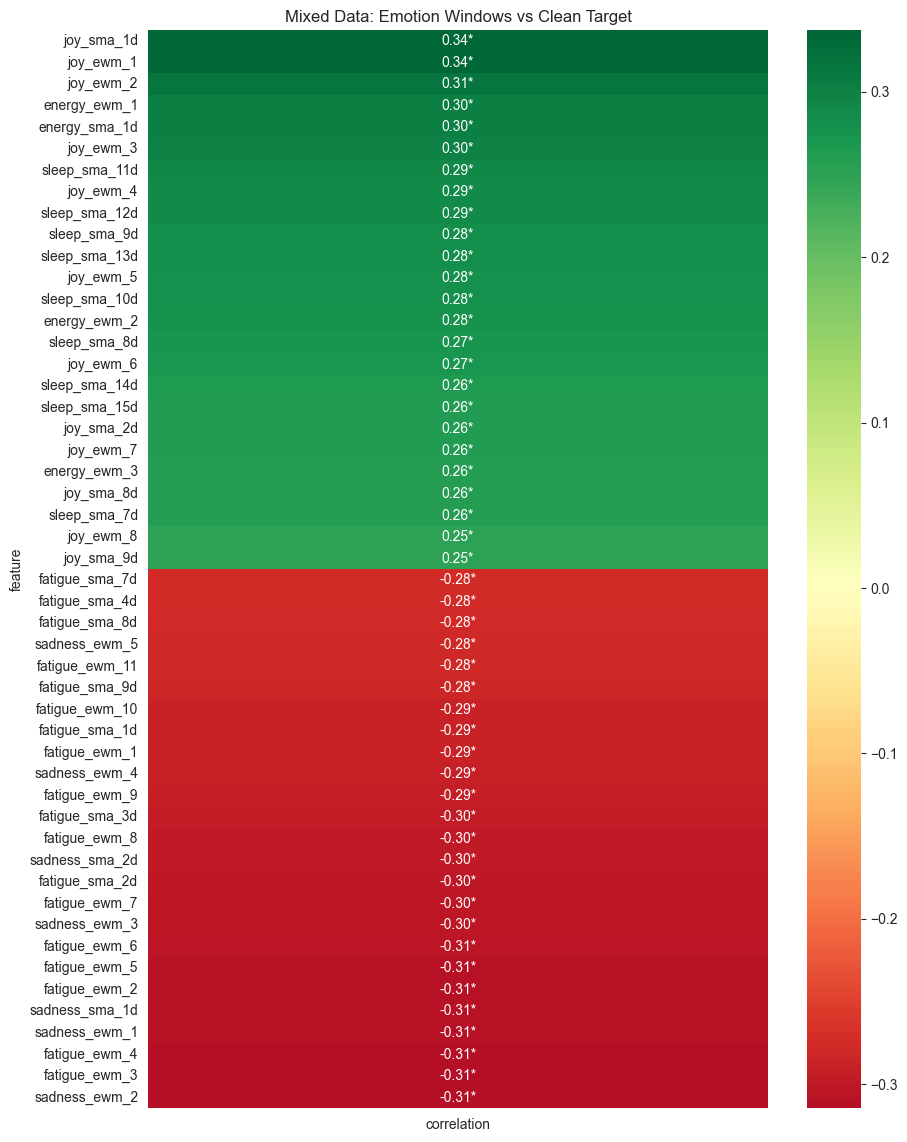

In [51]:
# Head(25) + Tail(25) chart for Mixed
plot_stat_heatmap(
    pd.concat([mixed_sig.head(25), mixed_sig.tail(25)]),
    "Mixed Data: Emotion Windows vs Clean Target",
)

#### Why the third graph was created (TOP Mixed Data)
To avoid multicollinearity and cluttering the model, it was decided to select the **Top-3** most significant time windows for each individual emotion. This allows us to isolate the "pure signal" of each emotional group and prepare a concise set of features for final training.

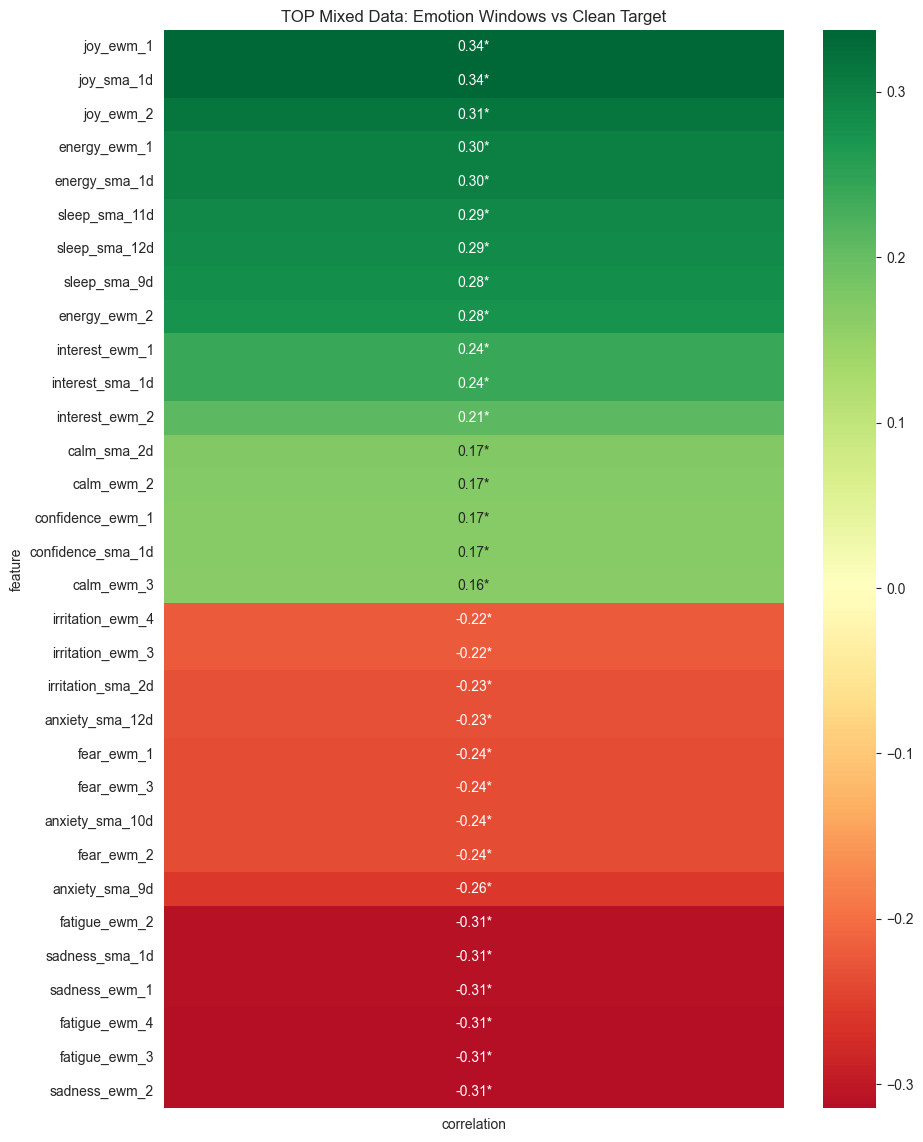

In [52]:
# Top critical features
st_mx_clean = get_critical_features(stats_mixed, top_n=3)
plot_stat_heatmap(st_mx_clean, "TOP Mixed Data: Emotion Windows vs Clean Target")

#### Conclusions and catalog selection logic
For automation, we iterate over the selected top features, calculating a priority of 1-7 based on the strength of the correlation and forming hypotheses for each feature.

**Key observations from the graph:**
* **Positive emotions are point:** `joy` and `energy` have the highest correlation precisely in short windows (`lag_1`, `sma_1d`). These are short-term spikes ("yesterday") that quickly fade away.
* **Negative emotions are lingering:** `fatigue`, `sadness` and `anxiety` manifest themselves best through **EWM** (exponential smoothing) and long windows. This confirms the hypothesis that negativity has a cumulative effect and "lags" with the user longer.
* **Sleep Foundation:** Sleep consistently shows significance over long horizons (9-12 days), acting as a basic moderator of mood.

This selection allows us to break through the baseline inertia by adding to the model precisely those temporal transformations that correspond to the nature of each specific emotion.

## 8. The impact of calendar and contextual factors
At this stage, we go beyond internal emotions and examine how external time cycles modulate the target variable `target_final`. This will help to understand the "rhythm" of the data and find patterns that are not directly related to mood logs.

### What we analyze:
* **Day of Week:** Looking for weekly cyclicality (for example, the "Monday effect" or "Friday uplift").
* **Weekend vs Weekday (Is Weekend):** Assessing the impact of work schedules on the general background.
* **Week:** Trends that may be related to the previous week.
* **Month Seasonality (Month):** Long-term trends that may be related to workload or time of year.
* **Temporal inertia:** Analyzing the extent to which yesterday's context determines today's result without taking into account emotional features.

**Goal:** Select significant calendar features to strengthen the model and ultimately break through the baseline.

### 8.1. Analysis of weekly cyclicity
**Goal:** To test the hypothesis that mood depends on the day of the week.

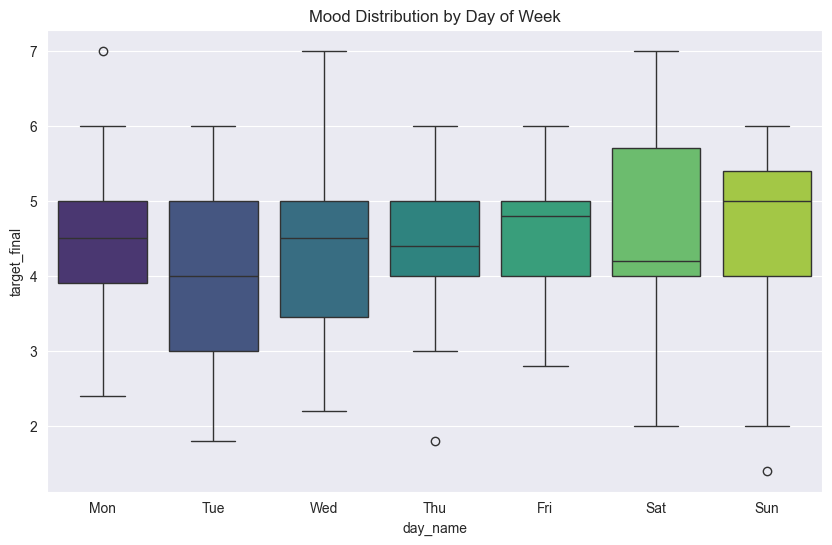

In [54]:
df_temp["day_of_week"] = df_temp.index.dayofweek
days_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
df_temp["day_name"] = df_temp["day_of_week"].map(days_map)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_temp,
    x="day_name",
    y="target_final",
    order=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    palette="viridis",
    hue="day_name",
    legend=False,
)
plt.title("Mood Distribution by Day of Week")
plt.show()

In [55]:
groups = [df_temp[df_temp["day_of_week"] == i]["target_final"].dropna() for i in range(7)]
f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA p-value: {p_val:.4f}")
if p_val < 0.05:
    print("Day of the week has a statistically significant effect!")
else:
    print("Day of the week is more of a noise than a stable factor.")

ANOVA p-value: 0.5154
Day of the week is more of a noise than a stable factor.


**Conclusions from the graph and test:**
* **Visually:** Saturday and Sunday have a slightly higher median and a "tightened" lower quartile, but the range of outliers and overlap between days is very large.
* **ANOVA (p-value: 0.5154):** No statistically significant difference between days of the week was found**. This means that mood depends more on internal factors (emotions, sleep) than on the name of the day in the calendar.
* **Solution for the model:** The `day_of_week` feature in the current data is more likely to be noise than a stable predictor. It will not be a priority when selecting features.

**Status:** The hypothesis about the effect of the day of the week is refuted.

### 8.2. "Weekdays vs Weekends" Analysis.
**Goal:** To test the hypothesis about the dependence of mood on weekends.

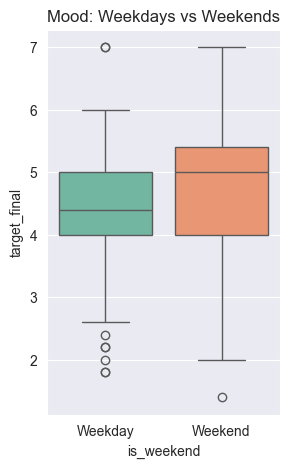

T-test p-value: 0.1048
Is_weekend is just noise. No stable difference found.


In [56]:
df_temp["is_weekend"] = df_temp.index.dayofweek.isin([5, 6]).astype(int)

plt.figure(figsize=(3, 5))
sns.boxplot(
    data=df_temp, x="is_weekend", y="target_final", palette="Set2", hue="is_weekend", legend=False
)
plt.xticks([0, 1], ["Weekday", "Weekend"])
plt.title("Mood: Weekdays vs Weekends")
plt.show()

weekday_mood = df_temp[df_temp["is_weekend"] == 0]["target_final"].dropna()
weekend_mood = df_temp[df_temp["is_weekend"] == 1]["target_final"].dropna()

t_stat, p_val = stats.ttest_ind(weekday_mood, weekend_mood)

print(f"T-test p-value: {p_val:.4f}")
if p_val < 0.05:
    print("Is_weekend is a SIGNIFICANT factor! 🎉")
else:
    print("Is_weekend is just noise. No stable difference found.")

**Conclusions:**
* **Visually:** Although the median mood is higher on weekends and the 75th percentile reaches higher values, the "boxes" (interquartile range) overlap greatly. There is also greater variability on weekends (longer "whiskers").
* **T-test (p-value: 0.1048):** The value is above 0.05, indicating the absence of a statistically significant difference. Even aggregating days into the "weekend" group does not give a stable signal that would override the internal emotional "noise".
* **Solution for the model:** The `is_weekend` feature has low predictive power. The model can use it as a secondary context, but it will not become a key factor in breaking the baseline.

**Status:** The hypothesis about the dominant effect of weekends is not confirmed (the signal is too weak).

### 8.3. Seasonality: Year-Month Trend Analysis
**Goal:** To examine the presence of long-term mood swings and the impact of specific periods of the year on the underlying emotional background.

ANOVA (Month) p-value: 0.0101


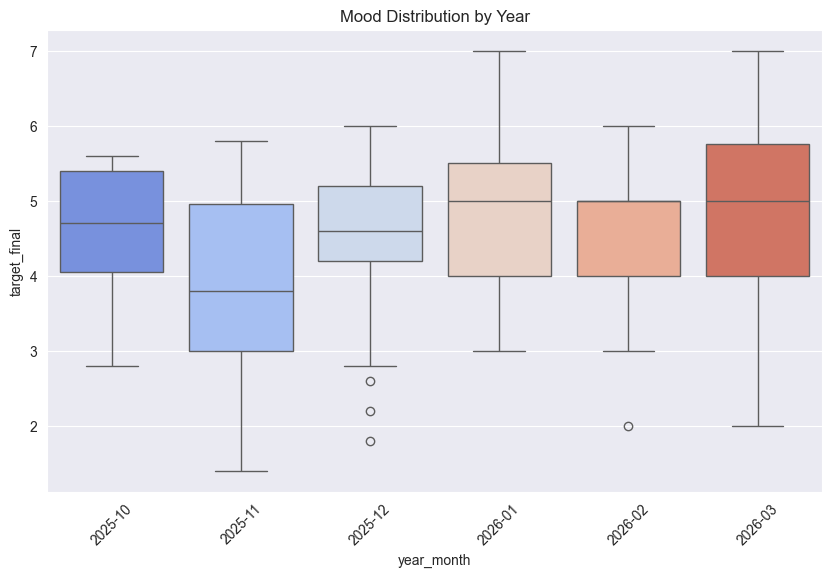

In [57]:
df_temp["month"] = df_temp.index.month
df_temp["year"] = df_temp.index.year

df_temp["year_month"] = df_temp.index.to_period("M").astype(str)

month_groups = [group["target_final"].dropna() for _, group in df_temp.groupby("month")]
f_stat_m, p_val_m = stats.f_oneway(*month_groups)

print(f"ANOVA (Month) p-value: {p_val_m:.4f}")

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_temp.sort_index(),
    x="year_month",
    y="target_final",
    hue="year_month",
    palette="coolwarm",
    legend=False,
)
plt.xticks(rotation=45)
plt.title("Mood Distribution by Year")
plt.show()

**Conclusions:**
* **Visually:** A clear dynamic is observed: a noticeable drop in the median in November 2025 (the lowest level) with subsequent gradual recovery and growth until March 2026. March 2026 looks like the most stable and positive period.
* **ANOVA (p-value: 0.0101):** The result is less than 0.05! This means that **month is a statistically significant factor**. The difference in mood between different months is not random.
* **Solution for the model:** The month feature must be included in the model. Since we are dealing with cyclicality, it should be presented not simply as a number, but through special transformations.

**Status:** The hypothesis of a seasonal effect is confirmed.

### 8.4. Weekly Dynamics: Micro-Seasonality Analysis (Weekly Trends)
**Goal:** To investigate medium-term mood fluctuations and check whether there are persistent "weekly streaks" (series of good or bad days).

In [58]:
weeks = df_temp.index.isocalendar().week
df_temp["week_num"] = weeks

week_groups = [
    df_temp[df_temp["week_num"] == w]["target_final"].dropna() for w in df_temp["week_num"].unique()
]
f_stat_w, p_val_w = stats.f_oneway(*week_groups)

print(f"ANOVA (Week) p-value: {p_val_w:.4f}")

ANOVA (Week) p-value: 0.0001


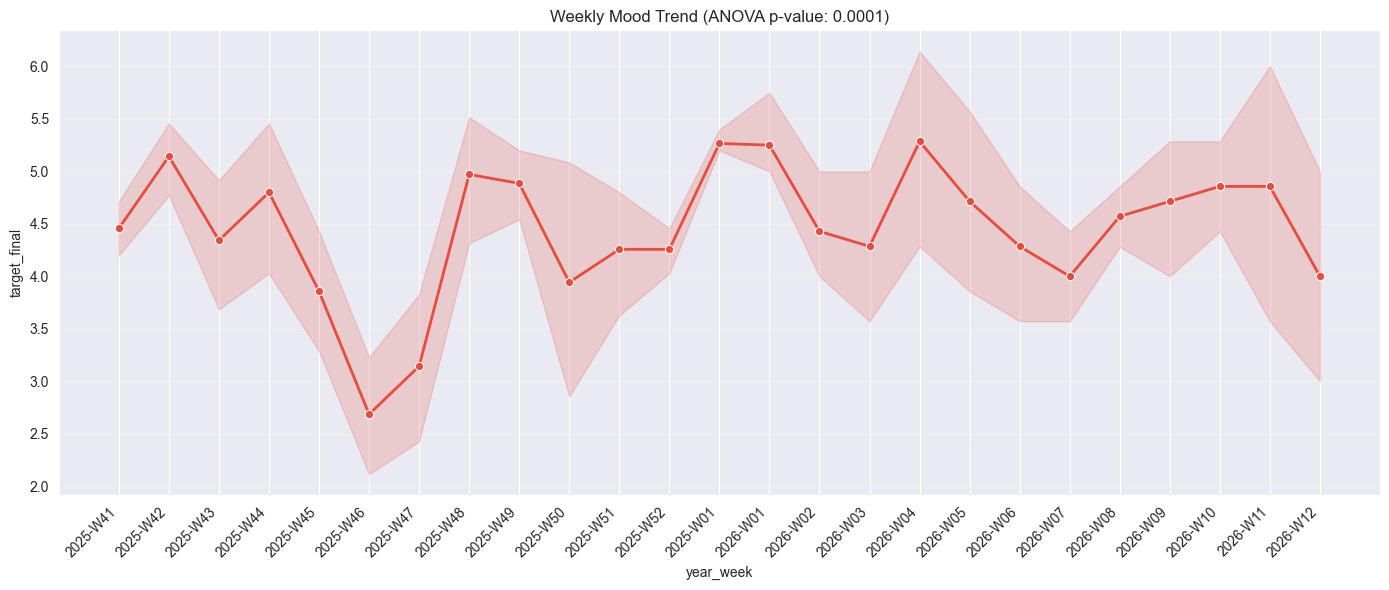

In [59]:
df_weekly = df_temp.copy().sort_index()
df_weekly["year_week"] = df_weekly.index.strftime("%Y-W%V")

unique_weeks = df_weekly["year_week"].unique()

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_weekly,
    x="year_week",
    y="target_final",
    marker="o",
    color="#e74c3c",
    errorbar=("ci", 95),
    linewidth=2,
)

plt.xticks(ticks=range(len(unique_weeks)), labels=unique_weeks, rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.2)
plt.title(f"Weekly Mood Trend (ANOVA p-value: {p_val_w:.4f})")
plt.tight_layout()
plt.show()

**Conclusions:**
* **Visually:** The graph demonstrates significant volatility. We see a deep dip in mid-November (week 46 of 2025) and a confident rise with the beginning of 2026. The confidence interval (shadow) shows periods of emotional instability (wide shadow) and relative calm (narrow shadow).
* **ANOVA (p-value: 0.0001):** This is the strongest result among all calendar factors! The meager p-value clearly confirms: **week of the year is a critical predictor**. The respondent's condition has a pronounced inertia, which lasts exactly on the 7-day segment.
* **Solution for the model:** The `week_num` attribute is mandatory. It will allow the model to take into account the "contextual band" in which the respondent is located, which will significantly improve the forecast compared to a simple analysis of individual days.

**Status:** The hypothesis of the dominant influence of weekly cyclicality is confirmed with the highest significance.

### 8.5. Contextual Inertia: The Impact of the Week's Background Mood

**Goal:** To test to what extent the "tail" of events from the past week determines today's state. **EWM** (Exponential Weighted Moving Average) was used because it better models human memory, giving more weight to recent days.

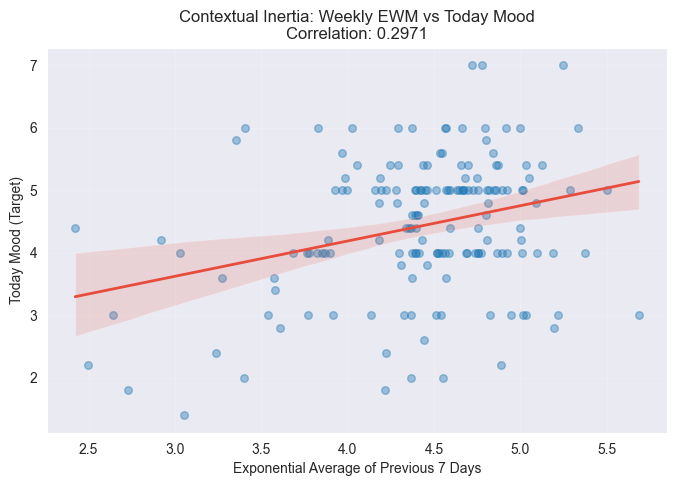

Correlation with weekly trend: 0.2971


In [60]:
df_temp["target_weekly_mean_lag1"] = (
    df_temp["target_final"].shift(1).ewm(span=7, adjust=False).mean()
)

corr_val = df_temp["target_final"].corr(df_temp["target_weekly_mean_lag1"])

plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_temp,
    x="target_weekly_mean_lag1",
    y="target_final",
    scatter_kws={"alpha": 0.4, "s": 30},
    line_kws={"color": "#e74c3c", "lw": 2},
)

plt.title(f"Contextual Inertia: Weekly EWM vs Today Mood\nCorrelation: {corr_val:.4f}", fontsize=12)
plt.xlabel("Exponential Average of Previous 7 Days")
plt.ylabel("Today Mood (Target)")
plt.grid(True, alpha=0.15)
plt.show()

print(f"Correlation with weekly trend: {corr_val:.4f}")

## Summary — Notebook 04: Temporal Dynamics & Lag Analysis

This notebook establishes the **temporal foundation** for the feature engineering pipeline. All analytical insights derived here directly informed which lag features were constructed and selected in the subsequent feature engineering phase (`05_feature_engineering_and_selection_strategy.ipynb`).

---

### Key Findings

**1. Stationarity Validation (ADF test + ACF decay)** All data segments (Historical, Modern, Synthetic Bridge) confirmed stationarity — demonstrating rapid ACF decay with no visible trend component. This means no differencing is required prior to modelling, and autoregressive lag features can be used directly.

**2. Target Stability (Leave-One-Out Stress Test)** Before running cross-correlation analysis, the synthetic `target_final` was validated by removing each emotion in turn and measuring the correlation with the actual mood log. All coefficients remained tightly bounded ($r \in [0.71, 0.79]$, $p < 0.05$). This confirms the target is a balanced composite indicator where no single emotion dominates, protecting the downstream pipeline from trivial self-correlations.

**3. Mood Autocorrelation (ACF / PACF)** Clean predictors were identified: 
* **Lag 1:** Primary autoregressive signal (PACF ~0.35).
* **Lag 4:** Micro-cycle, likely reflecting a work-week rhythm.
* **Lag 10:** Stable biorhythm echo. 
* *Note:* Lags 8 and 13 appeared significant in ACF but vanished in PACF, correctly identifying them as harmonic echoes of shorter cycles rather than independent signals.

**4. Sleep Cross-Correlation (CCF)** Sleep quality shows its strongest impact on mood with a **2-day delay** ($r=0.262$), rather than the next day — confirming physiological recovery inertia. A secondary weekly resonance at **Lag 7** ($r=0.241$) reflects routine and schedule effects. These findings directly justified the creation of `sleep_lag_2`, `sleep_lag_5`, and `sleep_lag_7`.

**5. Emotion Cross-Correlations (CCF with Factor Isolation)** * **Short-term inertia (Lags 1–3):** **Fatigue** is the most stable negative predictor; **Joy** and **Energy** show positive inertia up to Lag 2.
* **Weekly cycle (Lags 7–9):** **Calm** and **Anxiety** cluster around days 8–9, consistent with work-week accumulation effects.
* **14-day burnout signal:** **Joy** and **Energy** at Lags 14–15 show a *negative* correlation with current mood — our most counterintuitive yet valuable finding. High positive emotional states two weeks prior predict lower current mood, consistent with an "energy debt" or post-peak correction pattern.
* **Noise:** **Confidence** and **Irritation** remained noisy throughout and were excluded from deep lag modelling.

---

### Pipeline Impact: From Insight to Feature Selection

| Insight from Temporal Analysis | Outcome in Feature Engineering (Stage 3) |
| :--- | :--- |
| **Lag 1** as primary AR predictor | `target_final_lag_1` — selected in 11/11 successful model configurations. |
| **Lag 4** as micro-cycle signal | `target_final_lag_4` — selected in 4/11 successful configurations. |
| **Sleep Lag 7** as weekly resonance | `sleep_lag_7` — selected in 4/11 successful configurations. |
| **Fatigue Lags 1–2** as stable negative drivers | `fatigue_lag_2` — proved highly effective, exclusive to CatBoost family models. |
| **Joy/Interest** short-term dynamics | Derived as `joy_delta_1d` & `interest_delta_5d` — became top-3 most frequent features. |
| **Confidence/Irritation** high noise | Excluded beyond Lag 1; rightfully rejected by SFS in all successful configurations. |

---

### Methodological Notes

* **Data Leakage Prevention:** The CCF analysis was run using **factor isolation** (Leave-One-Out). Each emotion was subtracted from the synthetic target *before* computing its cross-correlation. This strict methodology prevents the trivial illusion of correlation that occurs when a feature is simply a mathematical component of the target.
* **Handling the Burnout Cycle:** The 14-day burnout cycle is a strong theoretical signal but proved too noisy to include as a direct categorical lag feature on a small dataset (160 records). However, discovering this cycle motivated the creation of the `mood_volatility_7d` rolling feature to act as a more stable proxy for emotional cycle phases.